# Comprehensive EDA: Power Outage Forecasting
Covers data audit, outage distribution, temporal patterns, weather feature importance, extreme event analysis, spatial analysis, and feature engineering signals.

In [4]:
!pip install netCDF4 xarray -q

In [5]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.colors import LogNorm
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = "data/"
ds = xr.open_dataset(f"{DATA_DIR}train.nc")

timestamps = pd.to_datetime(ds.timestamp.values)
locations = list(ds.location.values)
features = list(ds.feature.values)

outage = ds.out.transpose("timestamp", "location").values.astype(float)  # (T, L)
weather = ds.weather.transpose("timestamp", "location", "feature").values.astype(float)  # (T, L, F)
tracked = ds.tracked.transpose("timestamp", "location").values.astype(float)  # (T, L)

T, L = outage.shape
F = len(features)
print(f"Timestamps: {T}, Counties: {L}, Weather Features: {F}")
print(f"Period: {timestamps.min()} to {timestamps.max()}")
print(f"Duration: {(timestamps.max() - timestamps.min()).days} days")

Timestamps: 2161, Counties: 83, Weather Features: 109
Period: 2023-04-01 00:00:00 to 2023-06-30 00:00:00
Duration: 90 days


---
## 1. Data Audit

In [6]:
# 1a. Missing values
print("=== Missing Value Report ===")
print(f"Outage NaNs: {np.isnan(outage).sum()} / {outage.size} ({100*np.isnan(outage).sum()/outage.size:.2f}%)")
print(f"Weather NaNs: {np.isnan(weather).sum()} / {weather.size} ({100*np.isnan(weather).sum()/weather.size:.2f}%)")
print(f"Tracked NaNs: {np.isnan(tracked).sum()} / {tracked.size} ({100*np.isnan(tracked).sum()/tracked.size:.2f}%)")

# Per-feature NaN counts
feat_nan = np.isnan(weather).sum(axis=(0,1))  # (F,)
if feat_nan.max() > 0:
    print("\nFeatures with NaNs:")
    for i, f in enumerate(features):
        if feat_nan[i] > 0:
            print(f"  {f}: {feat_nan[i]} NaNs ({100*feat_nan[i]/(T*L):.2f}%)")
else:
    print("\nNo NaNs in any weather feature.")

=== Missing Value Report ===
Outage NaNs: 0 / 179363 (0.00%)
Weather NaNs: 0 / 19550567 (0.00%)
Tracked NaNs: 0 / 179363 (0.00%)

No NaNs in any weather feature.


In [7]:
# 1b. Tracked variable: constant or time-varying?
tracked_std_per_county = np.nanstd(tracked, axis=0)  # std over time for each county
print("=== Tracked Variable ===")
print(f"Mean tracked per county: {np.nanmean(tracked, axis=0).min():.0f} to {np.nanmean(tracked, axis=0).max():.0f}")
print(f"Std over time per county: min={tracked_std_per_county.min():.2f}, max={tracked_std_per_county.max():.2f}")
if tracked_std_per_county.max() < 1:
    print("-> Tracked is essentially constant over time (good proxy for county size).")
else:
    print("-> Tracked varies over time — check if it changes abruptly.")

=== Tracked Variable ===
Mean tracked per county: 2122 to 922425
Std over time per county: min=0.00, max=8526.26
-> Tracked varies over time — check if it changes abruptly.


In [8]:
# 1c. Timestamp gaps
diffs = np.diff(timestamps)
expected = pd.Timedelta(hours=1)
gaps = np.where(diffs != expected)[0]
if len(gaps) > 0:
    print(f"Found {len(gaps)} timestamp gaps:")
    for g in gaps[:10]:
        print(f"  {timestamps[g]} -> {timestamps[g+1]} (gap: {diffs[g]})")
else:
    print("No timestamp gaps — continuous hourly data.")

No timestamp gaps — continuous hourly data.


---
## 2. Outage Distribution & Sparsity

In [9]:
# 2a. Global outage statistics
flat = outage.flatten()
flat = flat[~np.isnan(flat)]
print("=== Outage Statistics ===")
for label, fn in [("Mean", np.mean), ("Median", np.median), ("Std", np.std),
                  ("Min", np.min), ("Max", np.max)]:
    print(f"  {label}: {fn(flat):.2f}")
print(f"  99th percentile: {np.percentile(flat, 99):.2f}")
print(f"  99.9th percentile: {np.percentile(flat, 99.9):.2f}")
print(f"  Zero fraction: {(flat == 0).sum() / len(flat):.4f} ({100*(flat==0).sum()/len(flat):.1f}%)")

=== Outage Statistics ===
  Mean: 45.25
  Median: 0.00
  Std: 452.27
  Min: 0.00
  Max: 23346.00
  99th percentile: 933.00
  99.9th percentile: 6215.29
  Zero fraction: 0.7047 (70.5%)


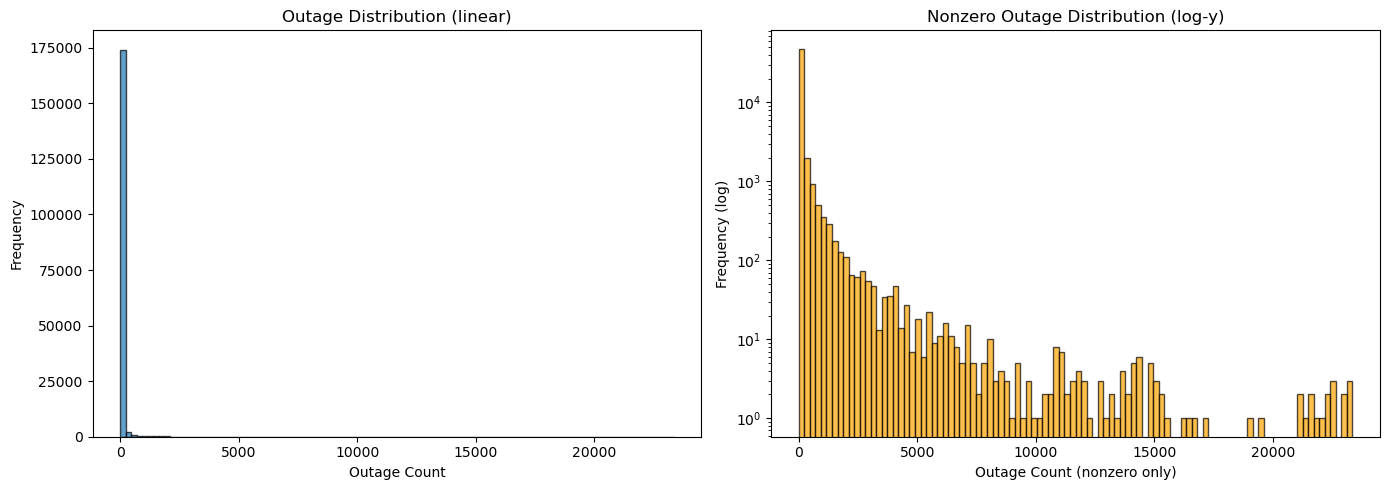

In [10]:
# 2b. Outage histogram (log scale to see tail)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(flat, bins=100, edgecolor='black', alpha=0.7)
axes[0].set_xlabel("Outage Count")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Outage Distribution (linear)")

nonzero = flat[flat > 0]
axes[1].hist(nonzero, bins=100, edgecolor='black', alpha=0.7, color='orange')
axes[1].set_yscale('log')
axes[1].set_xlabel("Outage Count (nonzero only)")
axes[1].set_ylabel("Frequency (log)")
axes[1].set_title("Nonzero Outage Distribution (log-y)")

plt.tight_layout()
plt.show()

In [11]:
# 2c. Per-county sparsity and outage stats
county_stats = pd.DataFrame({
    'county': locations,
    'mean_outage': np.nanmean(outage, axis=0),
    'max_outage': np.nanmax(outage, axis=0),
    'std_outage': np.nanstd(outage, axis=0),
    'zero_frac': [(outage[:, i] == 0).sum() / T for i in range(L)],
    'mean_tracked': np.nanmean(tracked, axis=0)
})
county_stats['outage_rate'] = county_stats['mean_outage'] / county_stats['mean_tracked']  # normalized
county_stats = county_stats.sort_values('mean_outage', ascending=False)

print("Top 10 counties by mean outage:")
print(county_stats.head(10).to_string(index=False))
print(f"\nBottom 5 counties by mean outage:")
print(county_stats.tail(5).to_string(index=False))

Top 10 counties by mean outage:
county  mean_outage  max_outage  std_outage  zero_frac  mean_tracked  outage_rate
 26125   797.721425     23346.0 2451.842497   0.000000 618067.284128     0.001291
 26163   764.807959     15143.0 1813.722751   0.000000 922425.000000     0.000829
 26099   426.029616     17047.0 1527.341153   0.000000 413676.000000     0.001030
 26161   249.882925     11889.0 1213.067175   0.028690 174442.516428     0.001432
 26081   108.065710      6841.0  488.138222   0.341509 297421.329014     0.000363
 26103    98.937992      7078.0  621.620880   0.715872  15972.713559     0.006194
 26145    92.611754      8704.0  682.226368   0.404905  97158.266081     0.000953
 26093    73.809348      2800.0  273.452113   0.146229  90497.496529     0.000816
 26115    69.374364      2817.0  252.151967   0.083295  75791.622860     0.000915
 26049    61.776030      5878.0  349.108835   0.317446 206651.711708     0.000299

Bottom 5 counties by mean outage:
county  mean_outage  max_outage

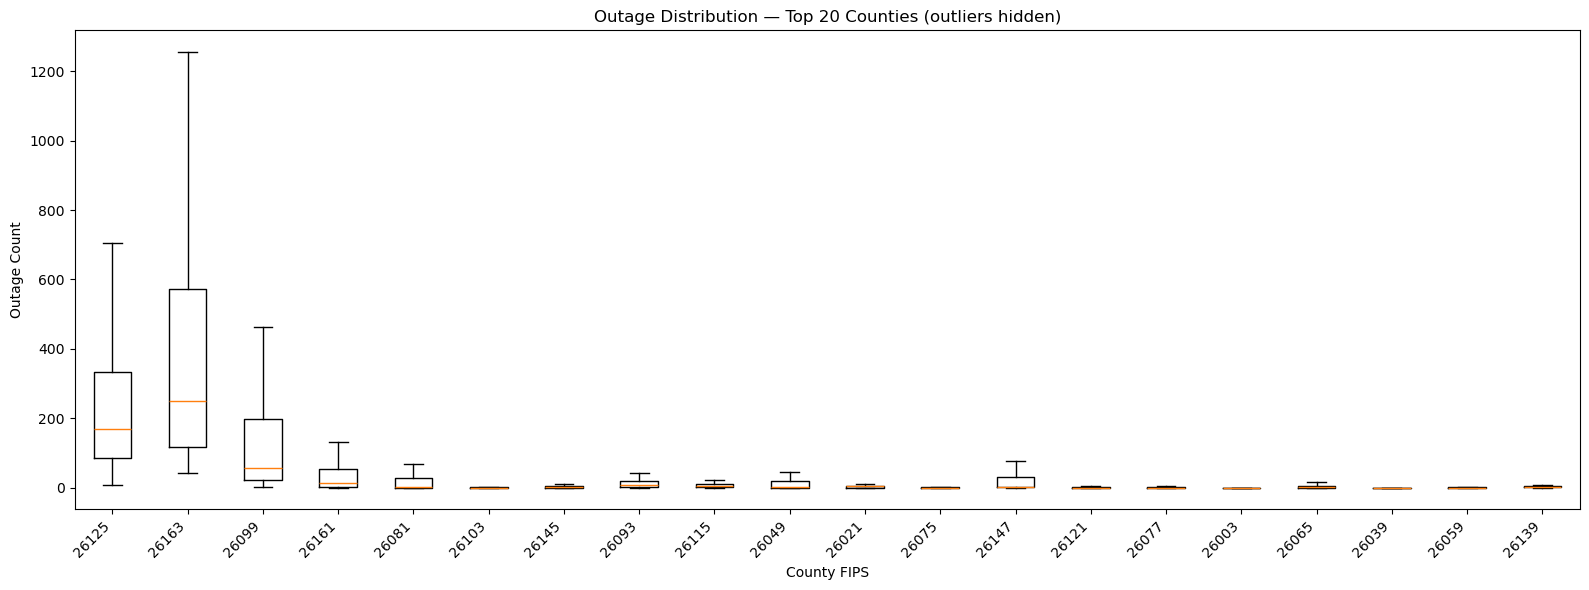

In [12]:
# 2d. Boxplot of outage counts per county (top 20)
top20 = county_stats.head(20)['county'].values
top20_idx = [locations.index(c) for c in top20]

fig, ax = plt.subplots(figsize=(16, 6))
data_for_box = [outage[:, i] for i in top20_idx]
ax.boxplot(data_for_box, labels=top20, showfliers=False)  # hide outliers for readability
ax.set_xlabel("County FIPS")
ax.set_ylabel("Outage Count")
ax.set_title("Outage Distribution — Top 20 Counties (outliers hidden)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

---
## 3. Temporal Patterns

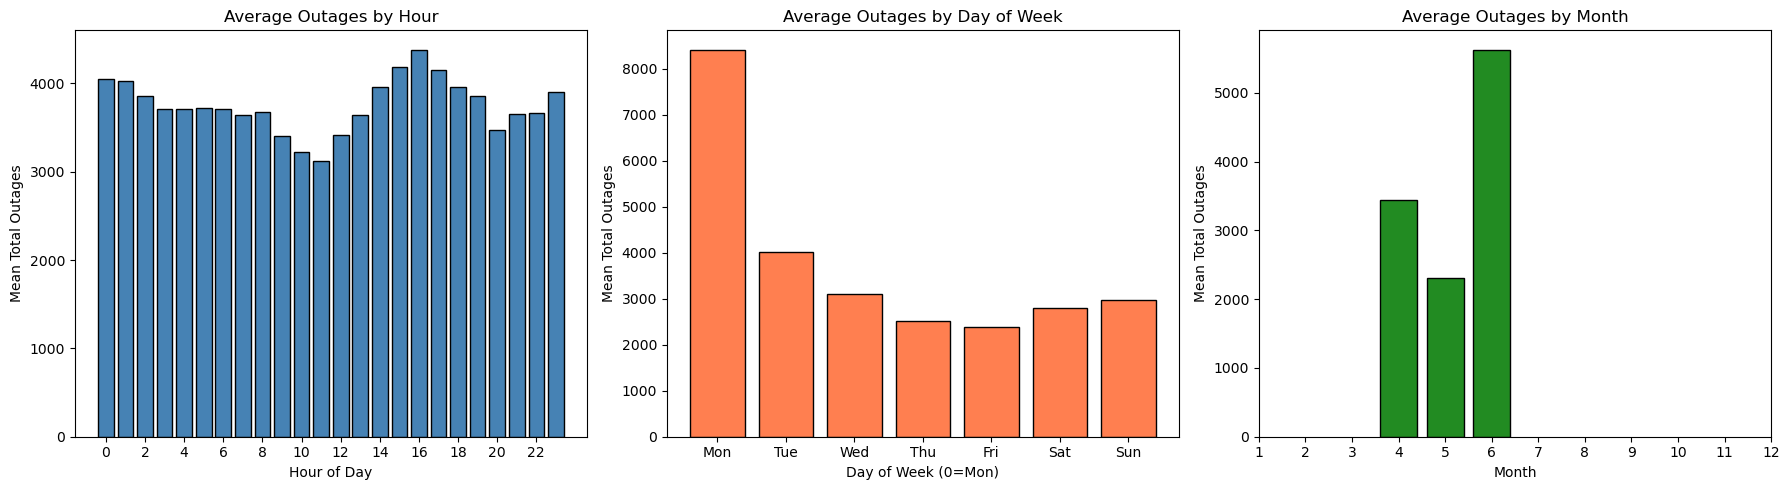

In [13]:
# 3a. Hour-of-day and day-of-week profiles
ts_df = pd.DataFrame({
    'hour': timestamps.hour,
    'dow': timestamps.dayofweek,
    'month': timestamps.month,
    'total_outage': np.nansum(outage, axis=1)  # sum across all counties per timestamp
})

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Hour of day
hourly = ts_df.groupby('hour')['total_outage'].mean()
axes[0].bar(hourly.index, hourly.values, color='steelblue', edgecolor='black')
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Mean Total Outages")
axes[0].set_title("Average Outages by Hour")
axes[0].set_xticks(range(0, 24, 2))

# Day of week
daily = ts_df.groupby('dow')['total_outage'].mean()
axes[1].bar(daily.index, daily.values, color='coral', edgecolor='black')
axes[1].set_xlabel("Day of Week (0=Mon)")
axes[1].set_ylabel("Mean Total Outages")
axes[1].set_title("Average Outages by Day of Week")
axes[1].set_xticks(range(7))
axes[1].set_xticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])

# Month
monthly = ts_df.groupby('month')['total_outage'].mean()
axes[2].bar(monthly.index, monthly.values, color='forestgreen', edgecolor='black')
axes[2].set_xlabel("Month")
axes[2].set_ylabel("Mean Total Outages")
axes[2].set_title("Average Outages by Month")
axes[2].set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

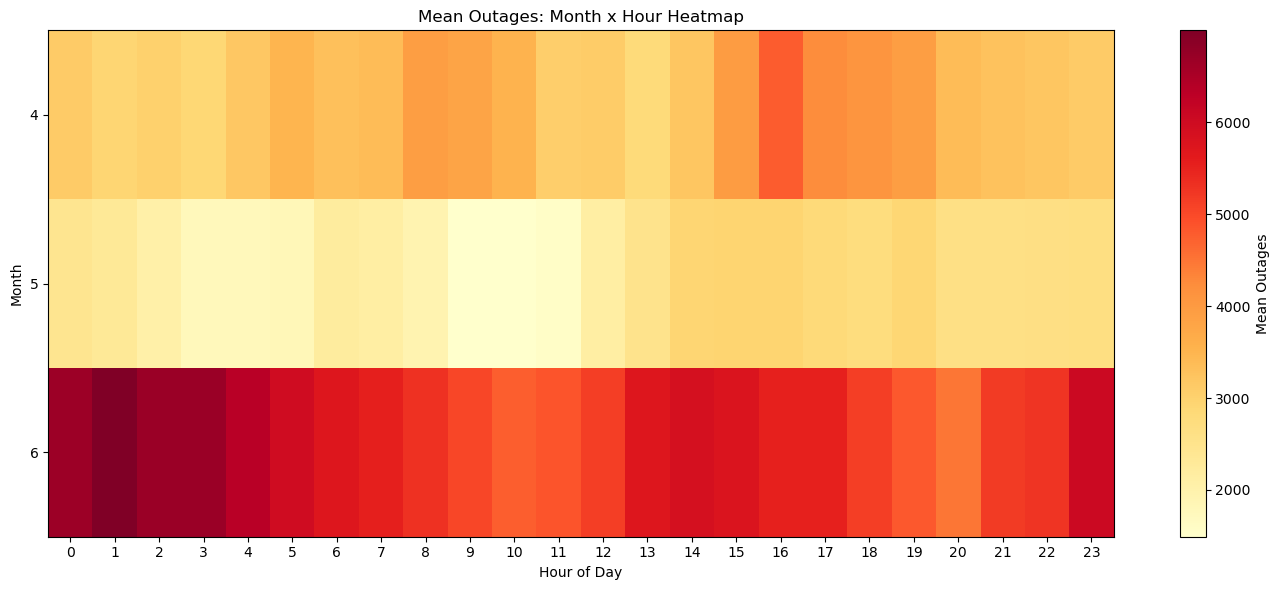

In [14]:
# 3b. Hour x Month heatmap
pivot = ts_df.groupby(['month', 'hour'])['total_outage'].mean().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(14, 6))
im = ax.imshow(pivot.values, aspect='auto', cmap='YlOrRd', interpolation='nearest')
ax.set_xlabel("Hour of Day")
ax.set_ylabel("Month")
ax.set_title("Mean Outages: Month x Hour Heatmap")
ax.set_xticks(range(24))
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index)
plt.colorbar(im, ax=ax, label='Mean Outages')
plt.tight_layout()
plt.show()

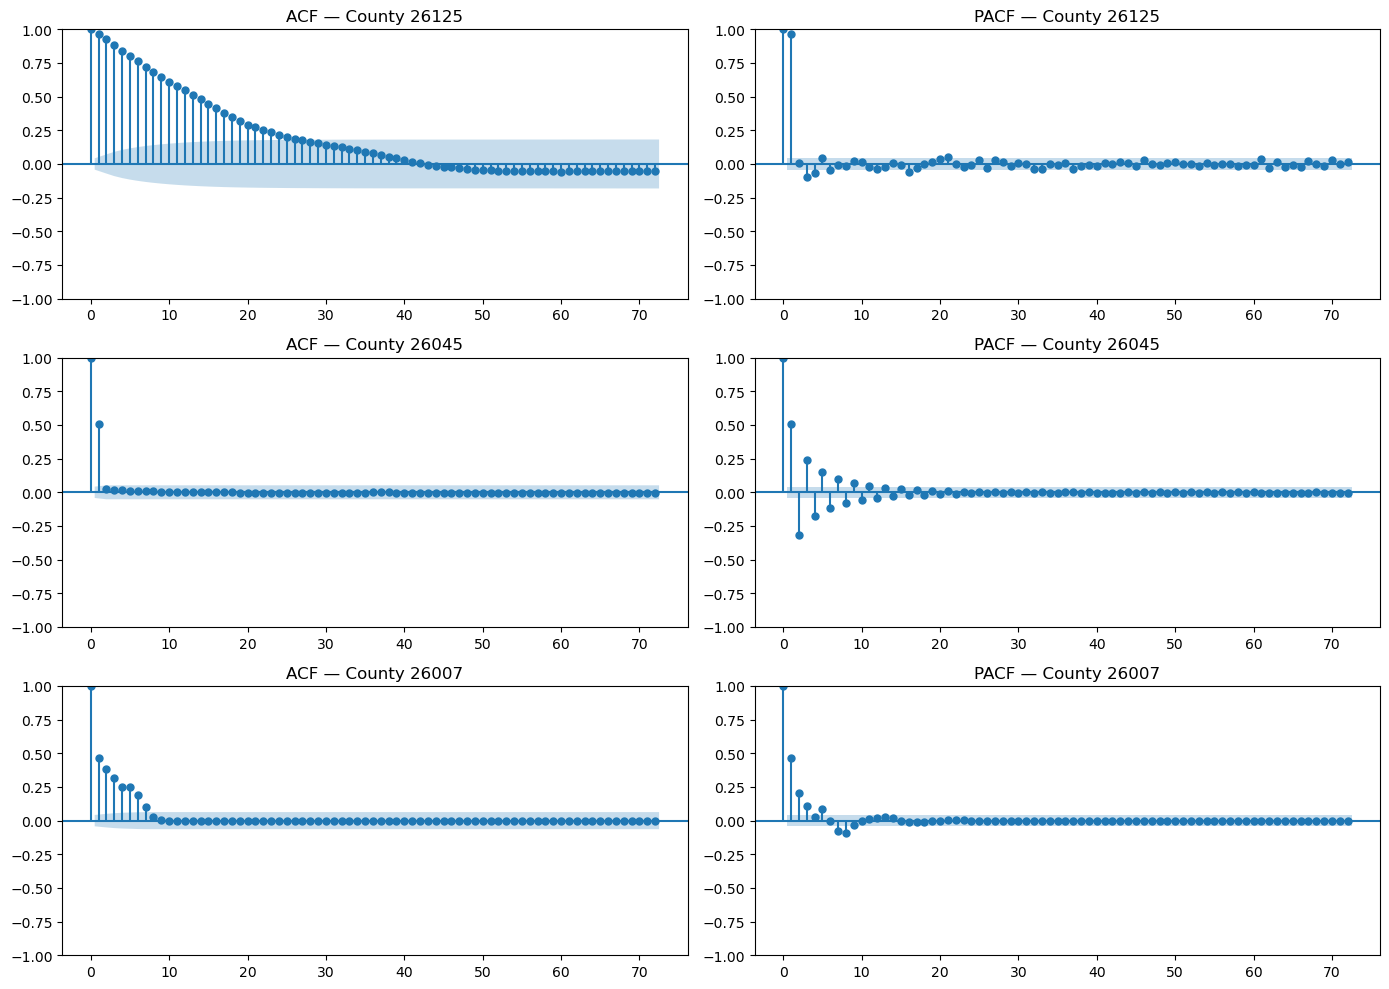

Hint: Significant PACF lags suggest AR order. 24h periodicity = seasonal component.


In [15]:
# 3c. ACF/PACF for a few representative counties
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

# Pick 3 counties: highest mean outage, median, lowest nonzero
sorted_counties = county_stats.sort_values('mean_outage', ascending=False)
sample_counties = [
    sorted_counties.iloc[0]['county'],   # highest
    sorted_counties.iloc[L//2]['county'], # median
    sorted_counties.iloc[-1]['county']    # lowest
]

fig, axes = plt.subplots(3, 2, figsize=(14, 10))
for row, county in enumerate(sample_counties):
    idx = locations.index(county)
    y = outage[:, idx]
    y = y[~np.isnan(y)]
    plot_acf(y, lags=72, ax=axes[row, 0], title=f"ACF — County {county}")
    plot_pacf(y, lags=72, ax=axes[row, 1], title=f"PACF — County {county}", method='ywm')

plt.tight_layout()
plt.show()
print("Hint: Significant PACF lags suggest AR order. 24h periodicity = seasonal component.")

---
## 4. Weather Feature Importance

In [16]:
# 4a. Correlation of each weather feature with outages (across all counties)
# Flatten: for each (t, l) pair, correlate weather[t,l,f] with outage[t,l]
out_flat = outage.reshape(-1)  # (T*L,)
w_flat = weather.reshape(-1, F)  # (T*L, F)

valid = ~(np.isnan(out_flat) | np.any(np.isnan(w_flat), axis=1))
out_v = out_flat[valid]
w_v = w_flat[valid]

correlations = np.array([np.corrcoef(w_v[:, i], out_v)[0, 1] for i in range(F)])

corr_df = pd.DataFrame({'feature': features, 'corr': correlations})
corr_df['abs_corr'] = corr_df['corr'].abs()
corr_df = corr_df.sort_values('abs_corr', ascending=False)

print("Top 20 weather features by |correlation| with outages:")
print(corr_df.head(20).to_string(index=False))

Top 20 weather features by |correlation| with outages:
  feature      corr  abs_corr
     cape  0.119191  0.119191
     pwat  0.089700  0.089700
      sh2  0.083554  0.083554
     gh_4  0.081504  0.081504
   cape_1  0.073289  0.073289
   sdlwrf  0.068874  0.068874
unknown_3  0.061608  0.061608
     refc  0.059532  0.059532
      lcc  0.055376  0.055376
     hail  0.054625  0.054625
    cnwat  0.054364  0.054364
      tcc  0.053949  0.053949
     pcdb  0.053770  0.053770
       gh -0.052808  0.052808
     lftx -0.052581  0.052581
    lftx4 -0.050992  0.050992
     gh_3  0.050361  0.050361
      sde  0.049588  0.049588
    tcc_1  0.049512  0.049512
        r  0.049113  0.049113


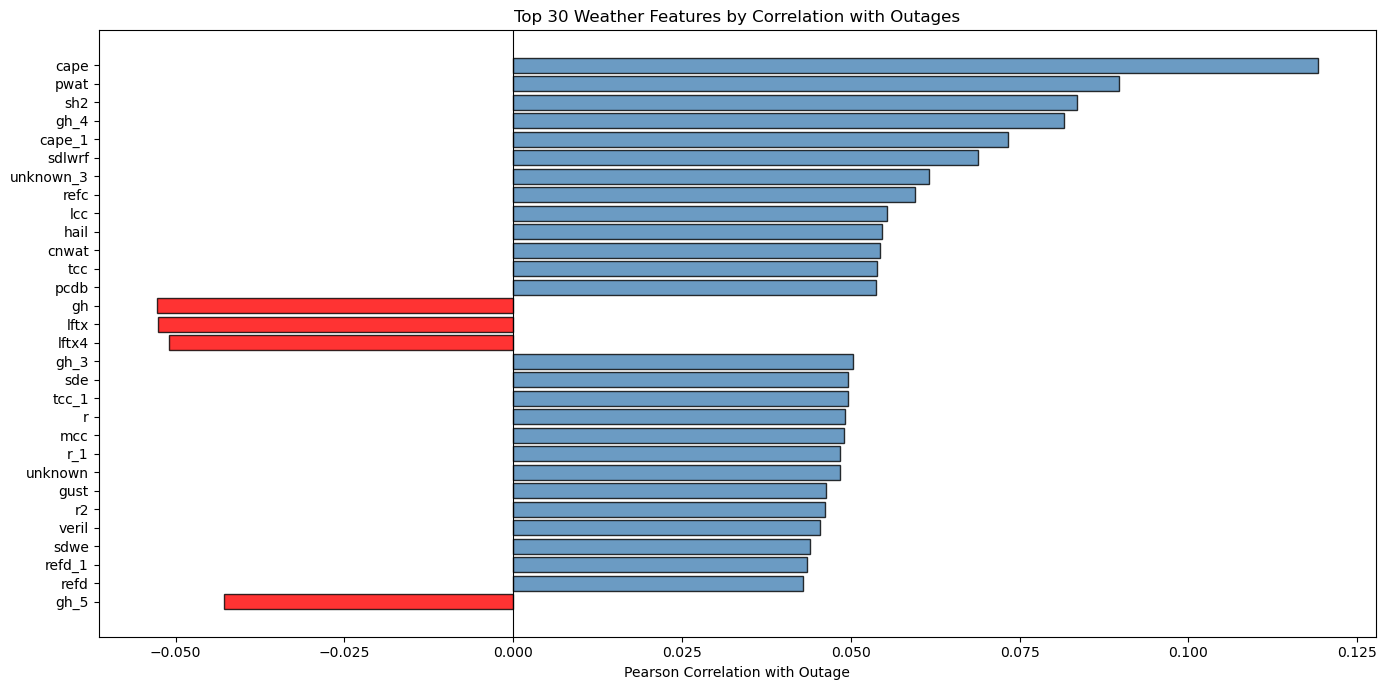

In [17]:
# 4b. Bar chart of top 30 features
top30 = corr_df.head(30)

fig, ax = plt.subplots(figsize=(14, 7))
colors = ['red' if c < 0 else 'steelblue' for c in top30['corr']]
ax.barh(range(len(top30)), top30['corr'].values, color=colors, edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(top30)))
ax.set_yticklabels(top30['feature'].values)
ax.set_xlabel("Pearson Correlation with Outage")
ax.set_title("Top 30 Weather Features by Correlation with Outages")
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

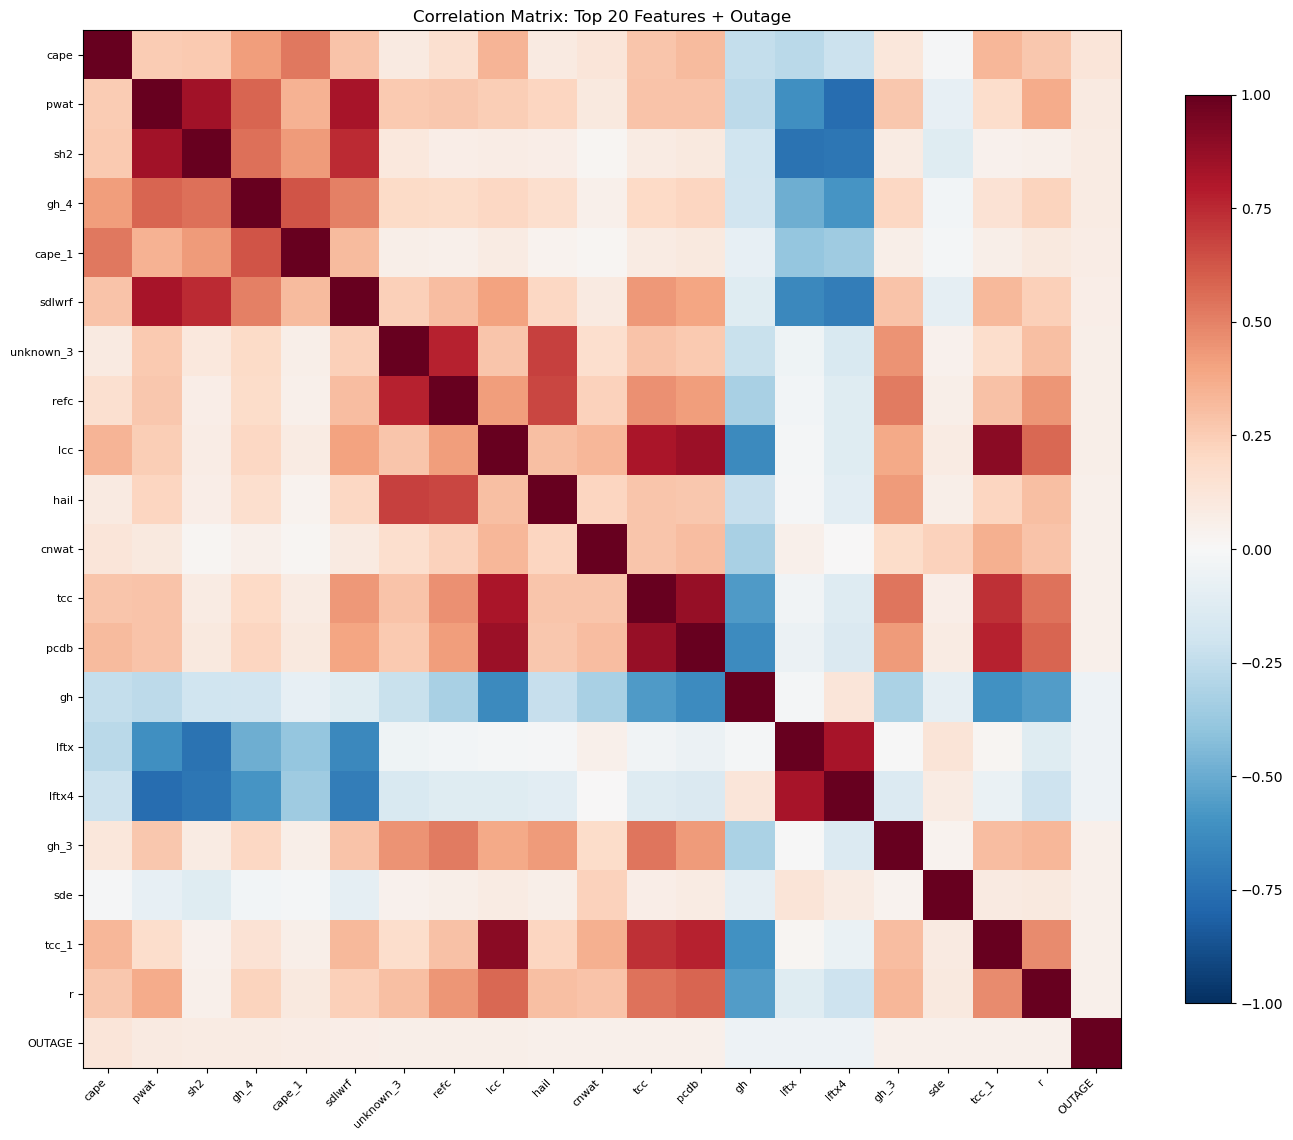

Look for feature clusters (redundancy) and which features correlate independently with outage.


In [18]:
# 4c. Feature-feature correlation heatmap (top 20 features + outage)
top20_feats = corr_df.head(20)['feature'].values
top20_idx_f = [features.index(f) for f in top20_feats]

# Build matrix: (T*L, 20+1) = top20 weather + outage
combo = np.column_stack([w_v[:, top20_idx_f], out_v])  # (N, 21)
combo_corr = np.corrcoef(combo.T)  # (21, 21)

labels = list(top20_feats) + ['OUTAGE']
fig, ax = plt.subplots(figsize=(14, 12))
im = ax.imshow(combo_corr, cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_xticks(range(len(labels)))
ax.set_yticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=8)
ax.set_yticklabels(labels, fontsize=8)
ax.set_title("Correlation Matrix: Top 20 Features + Outage")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()
print("Look for feature clusters (redundancy) and which features correlate independently with outage.")

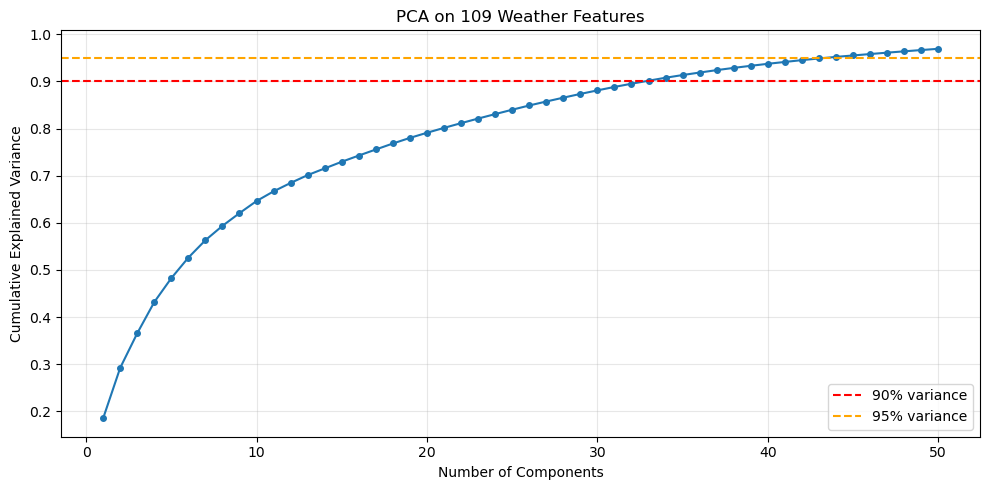

Components for 90% variance: 33
Components for 95% variance: 44


In [19]:
# 4d. PCA on weather features — how many components explain variance?
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# Subsample for speed (every 10th row)
w_sub = w_v[::10]
scaler = StandardScaler()
w_scaled = scaler.fit_transform(w_sub)

pca = PCA(n_components=min(50, F))
pca.fit(w_scaled)

cumvar = np.cumsum(pca.explained_variance_ratio_)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(range(1, len(cumvar)+1), cumvar, 'o-', markersize=4)
ax.axhline(0.90, color='red', linestyle='--', label='90% variance')
ax.axhline(0.95, color='orange', linestyle='--', label='95% variance')
ax.set_xlabel("Number of Components")
ax.set_ylabel("Cumulative Explained Variance")
ax.set_title("PCA on 109 Weather Features")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

n90 = np.searchsorted(cumvar, 0.90) + 1
n95 = np.searchsorted(cumvar, 0.95) + 1
print(f"Components for 90% variance: {n90}")
print(f"Components for 95% variance: {n95}")

---
## 5. Extreme Event Analysis

In [20]:
# 5a. Identify extreme outage events (top 1% of total outages per hour)
total_outage_per_hour = np.nansum(outage, axis=1)  # (T,)
threshold_99 = np.percentile(total_outage_per_hour, 99)
threshold_95 = np.percentile(total_outage_per_hour, 95)

extreme_mask = total_outage_per_hour >= threshold_99
high_mask = total_outage_per_hour >= threshold_95
normal_mask = total_outage_per_hour < threshold_95

print(f"99th percentile threshold: {threshold_99:.0f} total outages")
print(f"95th percentile threshold: {threshold_95:.0f} total outages")
print(f"Extreme hours (top 1%): {extreme_mask.sum()}")
print(f"High hours (top 5%): {high_mask.sum()}")

# Show when extreme events occur
extreme_times = timestamps[extreme_mask]
print(f"\nExtreme event timestamps (first 20):")
for t in extreme_times[:20]:
    print(f"  {t}")

99th percentile threshold: 56608 total outages
95th percentile threshold: 12708 total outages
Extreme hours (top 1%): 22
High hours (top 5%): 109

Extreme event timestamps (first 20):
  2023-06-26 00:00:00
  2023-06-26 01:00:00
  2023-06-26 02:00:00
  2023-06-26 03:00:00
  2023-06-26 04:00:00
  2023-06-26 05:00:00
  2023-06-26 06:00:00
  2023-06-26 07:00:00
  2023-06-26 08:00:00
  2023-06-26 09:00:00
  2023-06-26 10:00:00
  2023-06-26 11:00:00
  2023-06-26 12:00:00
  2023-06-26 13:00:00
  2023-06-26 14:00:00
  2023-06-26 15:00:00
  2023-06-26 16:00:00
  2023-06-26 17:00:00
  2023-06-26 18:00:00
  2023-06-26 19:00:00


Top 15 features that differ most during extreme outage hours (z-score):
feature    z_diff    abs_z
   cape  4.260248 4.260248
   pwat  2.769025 2.769025
    sh2  2.527733 2.527733
   gh_4  2.197153 2.197153
  cnwat  2.028701 2.028701
 cape_1  1.874957 1.874957
 sdlwrf  1.822822 1.822822
   lftx -1.508395 1.508395
  lftx4 -1.493467 1.493467
    d2m  1.354021 1.354021
      r  1.318481 1.318481
   pcdb  1.297838 1.297838
     gh -1.297600 1.297600
    lcc  1.292749 1.292749
    r_1  1.284052 1.284052


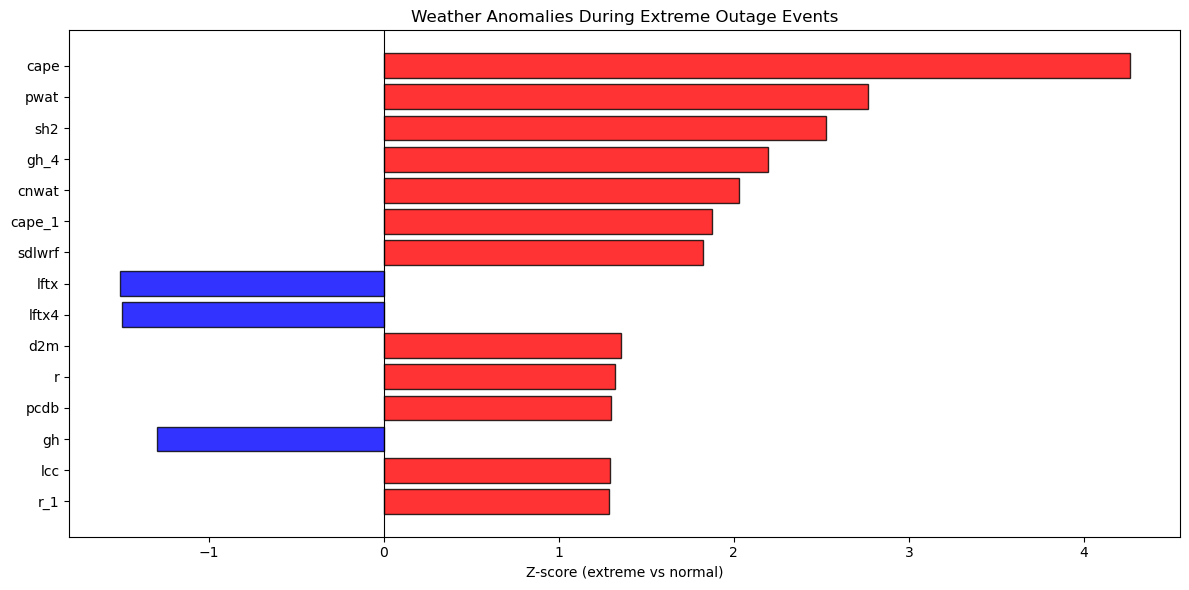

In [21]:
# 5b. Weather during extreme vs normal hours
# Compare mean weather feature values: extreme vs normal
w_mean_extreme = np.nanmean(weather[extreme_mask], axis=(0, 1))  # (F,)
w_mean_normal = np.nanmean(weather[normal_mask], axis=(0, 1))    # (F,)
w_std_normal = np.nanstd(weather[normal_mask].reshape(-1, F), axis=0)

# Z-score of extreme vs normal
z_diff = (w_mean_extreme - w_mean_normal) / np.where(w_std_normal == 0, 1, w_std_normal)

diff_df = pd.DataFrame({'feature': features, 'z_diff': z_diff})
diff_df['abs_z'] = diff_df['z_diff'].abs()
diff_df = diff_df.sort_values('abs_z', ascending=False)

print("Top 15 features that differ most during extreme outage hours (z-score):")
print(diff_df.head(15).to_string(index=False))

# Plot
top15_diff = diff_df.head(15)
fig, ax = plt.subplots(figsize=(12, 6))
colors = ['red' if z > 0 else 'blue' for z in top15_diff['z_diff']]
ax.barh(range(len(top15_diff)), top15_diff['z_diff'].values, color=colors, edgecolor='black', alpha=0.8)
ax.set_yticks(range(len(top15_diff)))
ax.set_yticklabels(top15_diff['feature'].values)
ax.set_xlabel("Z-score (extreme vs normal)")
ax.set_title("Weather Anomalies During Extreme Outage Events")
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

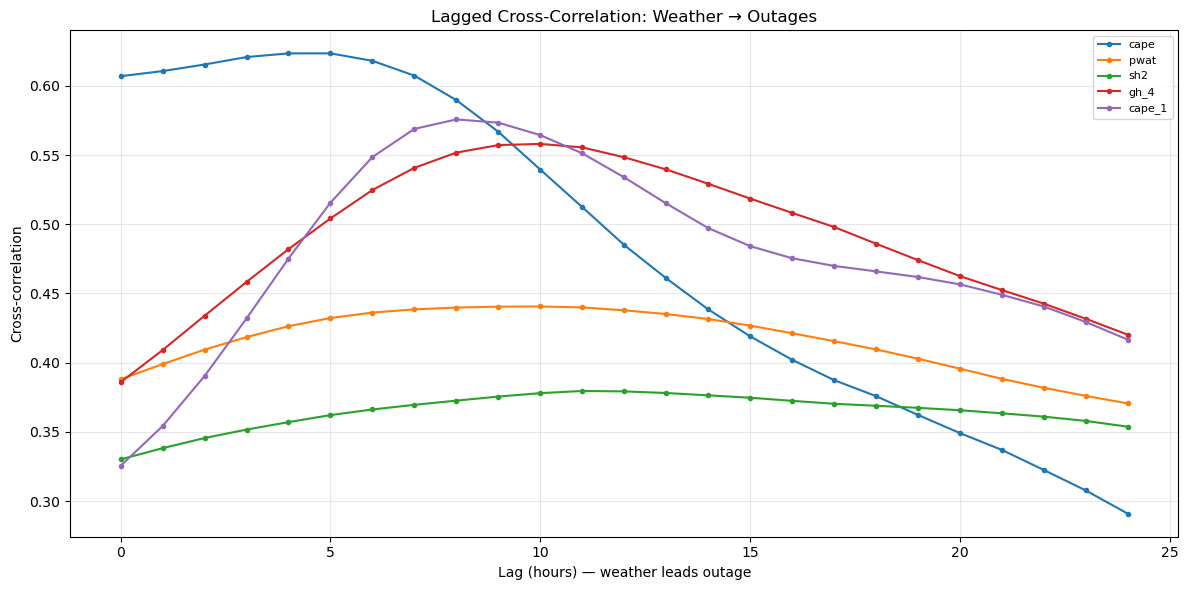

Peak lag tells you how many hours ahead weather signals predict outages.


In [22]:
# 5c. Lag analysis: do weather extremes precede outage spikes?
# For top 5 correlated features, compute cross-correlation at lags 0-24h
top5_feats = corr_df.head(5)['feature'].values
top5_fidx = [features.index(f) for f in top5_feats]

# Use total outage per hour and mean weather per hour across counties
w_hourly_mean = np.nanmean(weather, axis=1)  # (T, F)

max_lag = 24
fig, ax = plt.subplots(figsize=(12, 6))

for feat_name, fidx in zip(top5_feats, top5_fidx):
    w_series = w_hourly_mean[:, fidx]
    cross_corr = []
    for lag in range(max_lag + 1):
        if lag == 0:
            c = np.corrcoef(w_series, total_outage_per_hour)[0, 1]
        else:
            c = np.corrcoef(w_series[:-lag], total_outage_per_hour[lag:])[0, 1]
        cross_corr.append(c)
    ax.plot(range(max_lag + 1), cross_corr, 'o-', label=feat_name, markersize=3)

ax.set_xlabel("Lag (hours) — weather leads outage")
ax.set_ylabel("Cross-correlation")
ax.set_title("Lagged Cross-Correlation: Weather → Outages")
ax.legend(fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print("Peak lag tells you how many hours ahead weather signals predict outages.")

---
## 6. Spatial Analysis

In [23]:
# 6a. County-level summary table
county_summary = county_stats[['county', 'mean_outage', 'max_outage', 'std_outage',
                                'zero_frac', 'mean_tracked', 'outage_rate']].copy()
county_summary = county_summary.sort_values('outage_rate', ascending=False)

print("Top 10 counties by outage RATE (outages / tracked):")
print(county_summary.head(10).to_string(index=False))

print(f"\nCorrelation between county size (tracked) and mean outage: "
      f"{np.corrcoef(county_stats['mean_tracked'], county_stats['mean_outage'])[0,1]:.3f}")
print(f"Correlation between county size (tracked) and outage rate: "
      f"{np.corrcoef(county_stats['mean_tracked'], county_stats['outage_rate'])[0,1]:.3f}")

Top 10 counties by outage RATE (outages / tracked):
county  mean_outage  max_outage  std_outage  zero_frac  mean_tracked  outage_rate
 26013    15.410921      1263.0   95.818308   0.901435   2277.660342     0.006766
 26103    98.937992      7078.0  621.620880   0.715872  15972.713559     0.006194
 26003    33.974086      3064.0  225.737381   0.884776   9216.727441     0.003686
 26039    32.970384      3292.0  303.959111   0.920407  11886.614993     0.002774
 26053    20.119389      2424.0  133.356753   0.702915  10349.181860     0.001944
 26011    19.776030      2094.0  168.765328   0.915317  11369.694123     0.001739
 26097    15.655715      1348.0   86.923051   0.905599   9848.813512     0.001590
 26059    32.619158      2878.0  148.789590   0.747339  20705.970847     0.001575
 26095     3.279500      1465.0   54.944477   0.991671   2122.013882     0.001545
 26161   249.882925     11889.0 1213.067175   0.028690 174442.516428     0.001432

Correlation between county size (tracked) and

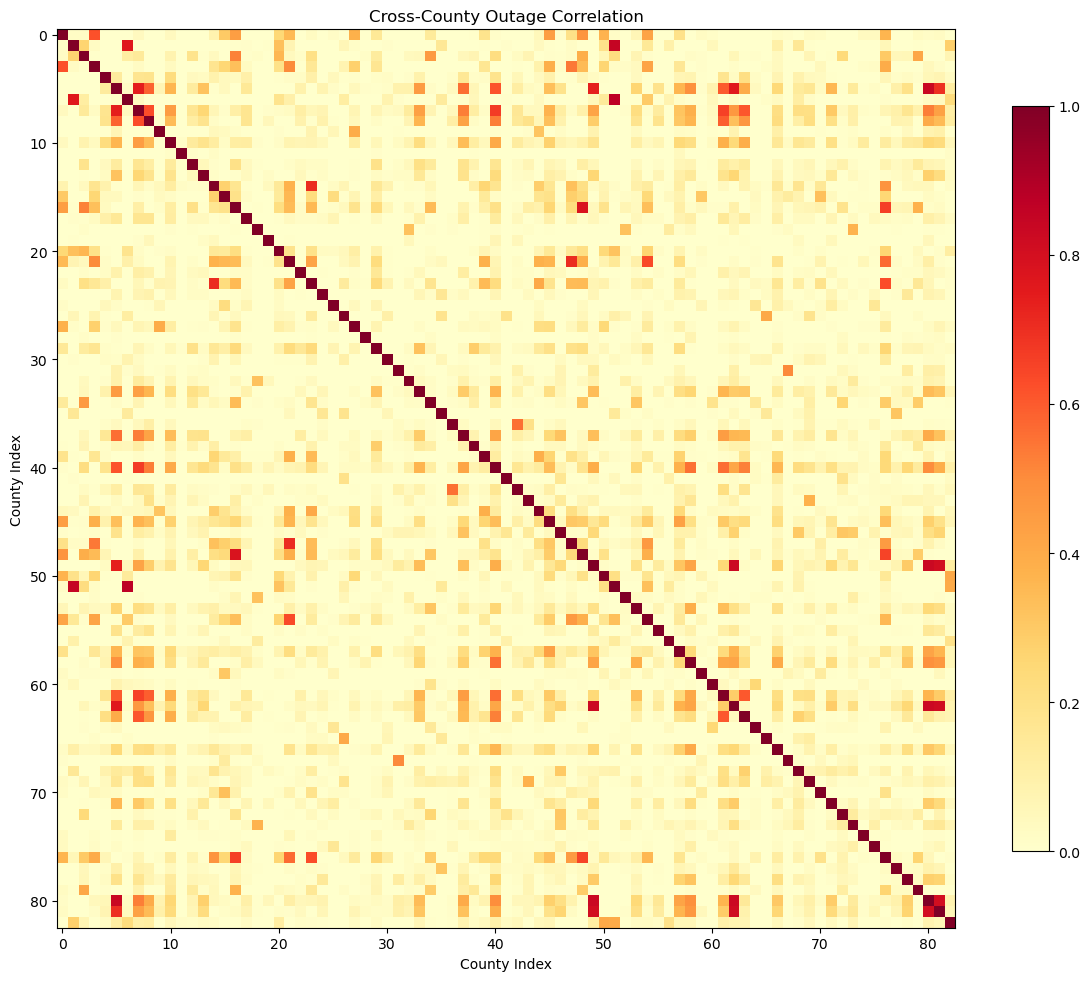

Top 10 most correlated county pairs:
  26013 <-> 26103: 0.870
  26003 <-> 26103: 0.845
  26011 <-> 26161: 0.834
  26099 <-> 26161: 0.832
  26125 <-> 26161: 0.828
  26099 <-> 26125: 0.825
  26125 <-> 26163: 0.814
  26099 <-> 26163: 0.808
  26161 <-> 26163: 0.802
  26033 <-> 26097: 0.779


In [24]:
# 6b. Cross-county correlation matrix (do neighbors spike together?)
# Compute pairwise correlation of outage time series between all counties
county_corr = np.corrcoef(outage.T)  # (L, L)

fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(county_corr, cmap='YlOrRd', vmin=0, vmax=1)
ax.set_title("Cross-County Outage Correlation")
ax.set_xlabel("County Index")
ax.set_ylabel("County Index")
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.show()

# Find most correlated county pairs
upper_tri = np.triu_indices(L, k=1)
pair_corrs = county_corr[upper_tri]
top_pairs = np.argsort(pair_corrs)[::-1][:10]

print("Top 10 most correlated county pairs:")
for p in top_pairs:
    i, j = upper_tri[0][p], upper_tri[1][p]
    print(f"  {locations[i]} <-> {locations[j]}: {county_corr[i,j]:.3f}")

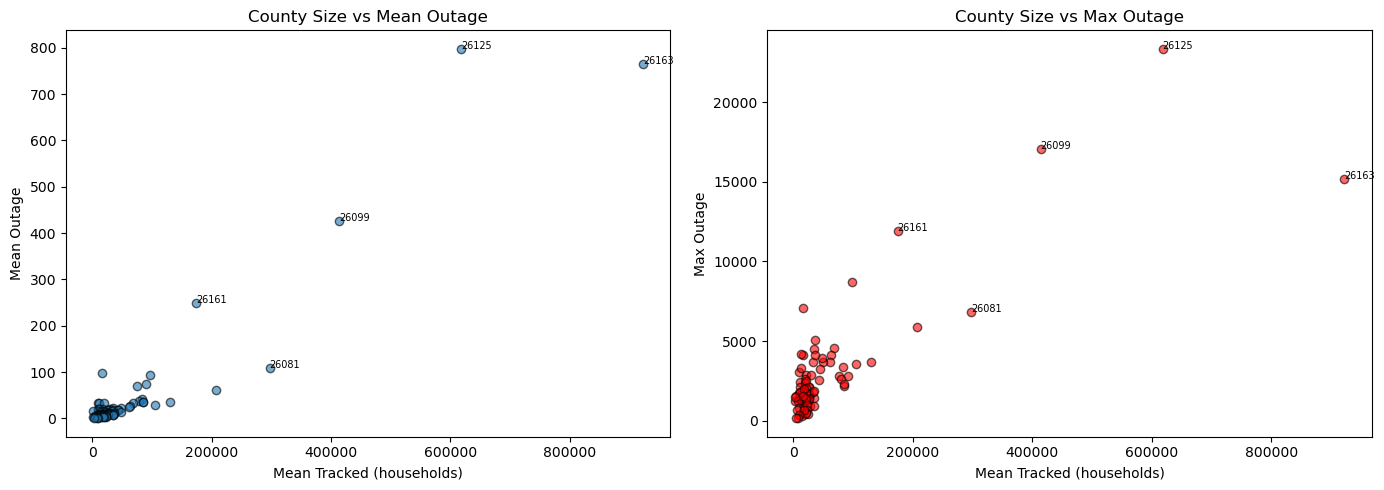

In [25]:
# 6c. Scatter: county size vs outage severity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(county_stats['mean_tracked'], county_stats['mean_outage'], alpha=0.6, edgecolor='black')
axes[0].set_xlabel("Mean Tracked (households)")
axes[0].set_ylabel("Mean Outage")
axes[0].set_title("County Size vs Mean Outage")
# label top 5
for _, row in county_stats.head(5).iterrows():
    axes[0].annotate(str(row['county']), (row['mean_tracked'], row['mean_outage']), fontsize=7)

axes[1].scatter(county_stats['mean_tracked'], county_stats['max_outage'], alpha=0.6, edgecolor='black', color='red')
axes[1].set_xlabel("Mean Tracked (households)")
axes[1].set_ylabel("Max Outage")
axes[1].set_title("County Size vs Max Outage")
for _, row in county_stats.head(5).iterrows():
    axes[1].annotate(str(row['county']), (row['mean_tracked'], row['max_outage']), fontsize=7)

plt.tight_layout()
plt.show()

---
## 7. Feature Engineering Signals

In [26]:
# 7a. Rolling window features — check if they improve correlation with outages
# Pick top 3 correlated raw features
top3_feats = corr_df.head(3)['feature'].values
top3_fidx = [features.index(f) for f in top3_feats]

# Test rolling windows on county-averaged data
windows = [3, 6, 12, 24]

print("Correlation of rolling features with total outages:\n")
print(f"{'Feature':<20} {'Raw':>8}", end="")
for w in windows:
    print(f" {'roll_'+str(w)+'h':>10}", end="")
print()
print("-" * 70)

for feat_name, fidx in zip(top3_feats, top3_fidx):
    raw = w_hourly_mean[:, fidx]
    raw_corr = np.corrcoef(raw, total_outage_per_hour)[0, 1]
    print(f"{feat_name:<20} {raw_corr:>8.4f}", end="")
    for w in windows:
        rolled = pd.Series(raw).rolling(w, min_periods=1).mean().values
        rc = np.corrcoef(rolled, total_outage_per_hour)[0, 1]
        print(f" {rc:>10.4f}", end="")
    print()

Correlation of rolling features with total outages:

Feature                   Raw    roll_3h    roll_6h   roll_12h   roll_24h
----------------------------------------------------------------------
cape                   0.6069     0.6236     0.6513     0.6778     0.6263
pwat                   0.3880     0.4007     0.4166     0.4375     0.4475
sh2                    0.3302     0.3397     0.3509     0.3675     0.3783


In [27]:
# 7b. Rate-of-change features
print("Correlation of rate-of-change features with total outages:\n")
print(f"{'Feature':<20} {'Raw':>8} {'diff_1h':>10} {'diff_3h':>10} {'diff_6h':>10}")
print("-" * 60)

for feat_name, fidx in zip(top3_feats, top3_fidx):
    raw = w_hourly_mean[:, fidx]
    raw_corr = np.corrcoef(raw, total_outage_per_hour)[0, 1]
    
    results = [f"{feat_name:<20}", f"{raw_corr:>8.4f}"]
    for d in [1, 3, 6]:
        diff = np.zeros_like(raw)
        diff[d:] = raw[d:] - raw[:-d]
        dc = np.corrcoef(diff, total_outage_per_hour)[0, 1]
        results.append(f"{dc:>10.4f}")
    print(" ".join(results))

Correlation of rate-of-change features with total outages:

Feature                   Raw    diff_1h    diff_3h    diff_6h
------------------------------------------------------------
cape                   0.6069    -0.0119    -0.0211    -0.0084
pwat                   0.3880    -0.0700    -0.1237    -0.1233
sh2                    0.3302    -0.0475    -0.0838    -0.0949


In [28]:
# 7c. Outage lag features — how well does past outage predict future?
print("Autocorrelation of total outages at various lags:\n")
lags = [1, 2, 3, 6, 12, 24, 48]
for lag in lags:
    ac = np.corrcoef(total_outage_per_hour[lag:], total_outage_per_hour[:-lag])[0, 1]
    print(f"  Lag {lag:>2}h: {ac:.4f}")
print("\nHigh autocorrelation at lag 1-3h means recent outage history is very predictive.")

Autocorrelation of total outages at various lags:

  Lag  1h: 0.9792
  Lag  2h: 0.9520
  Lag  3h: 0.9211
  Lag  6h: 0.8194
  Lag 12h: 0.6262
  Lag 24h: 0.2853
  Lag 48h: -0.0025

High autocorrelation at lag 1-3h means recent outage history is very predictive.


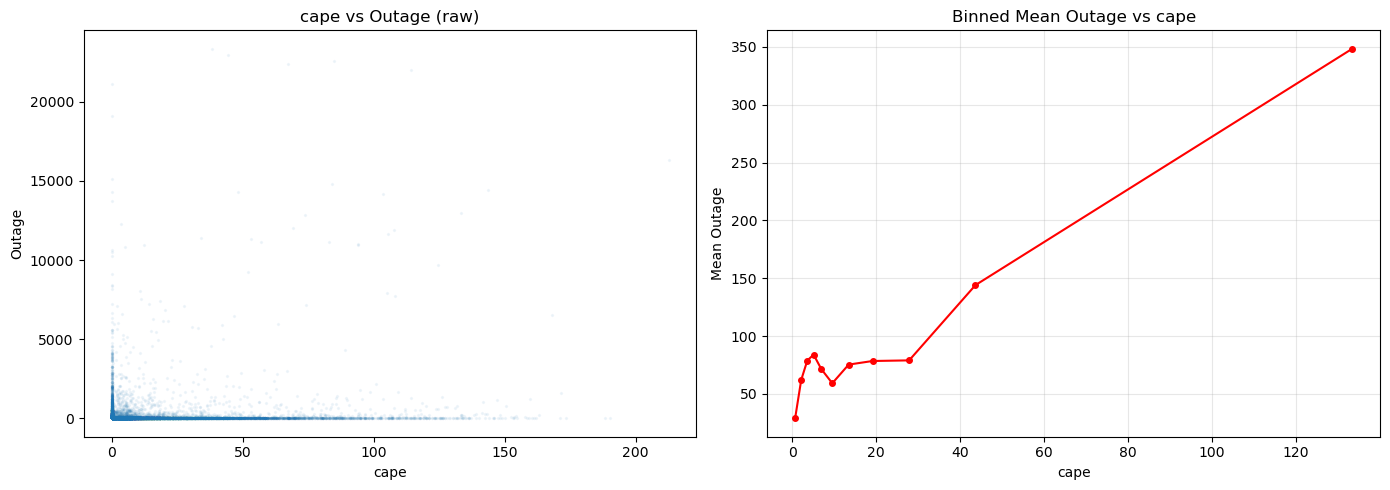

If the binned mean curve is non-monotonic, consider nonlinear transforms or tree-based models.


In [29]:
# 7d. Scatter: top feature vs outage (nonlinear check)
top_feat = corr_df.iloc[0]['feature']
top_fidx = features.index(top_feat)

# Sample for speed
np.random.seed(42)
sample_idx = np.random.choice(len(out_v), size=min(50000, len(out_v)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(w_v[sample_idx, top_fidx], out_v[sample_idx], alpha=0.05, s=2)
axes[0].set_xlabel(top_feat)
axes[0].set_ylabel("Outage")
axes[0].set_title(f"{top_feat} vs Outage (raw)")

# Binned mean to see the trend clearly
feat_vals = w_v[:, top_fidx]
bins = np.percentile(feat_vals, np.linspace(0, 100, 50))
bin_idx = np.digitize(feat_vals, bins)
bin_means = [np.mean(out_v[bin_idx == b]) if (bin_idx == b).sum() > 0 else np.nan for b in range(1, len(bins))]
bin_centers = 0.5 * (bins[:-1] + bins[1:])

axes[1].plot(bin_centers, bin_means, 'o-', markersize=4, color='red')
axes[1].set_xlabel(top_feat)
axes[1].set_ylabel("Mean Outage")
axes[1].set_title(f"Binned Mean Outage vs {top_feat}")
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
print("If the binned mean curve is non-monotonic, consider nonlinear transforms or tree-based models.")

---
## 8. Key Takeaways (fill in after running)

After running this EDA, summarize:

1. **Sparsity**: What fraction of observations are zero? Does RMSE favor predicting zeros vs capturing spikes?
2. **Temporal patterns**: Is there strong hour-of-day or seasonal structure? Should you add cyclical time features?
3. **Top weather features**: Which 10-15 features matter most? Can you drop the rest or use PCA?
4. **Extreme events**: What weather conditions precede spikes? How many hours of lead time?
5. **Spatial structure**: Do counties spike together? Is per-county modeling necessary or can you share parameters?
6. **Feature engineering**: Do rolling/lag/diff features improve correlation? What windows work best?
7. **Policy insight**: Which counties have the highest outage rates and largest populations? These are candidates for generator placement.